In [1]:
import sys

print(sys.executable)

/Users/varsharajesh/retail-intent/venv/bin/python3


In [4]:
import pandas as pd

df = pd.read_parquet("../data/events_sample.parquet")
print(df.shape)
df.head()

(3396657, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00+00:00,view,44600062,2103807459595387724,None,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00+00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:15+00:00,view,44600062,2103807459595387724,None,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
3,2019-10-01 00:01:24+00:00,view,1004785,2053013555631882655,electronics.smartphone,huawei,278.55,514336739,cccc58c1-4986-4d08-b595-d837c0c7d514
4,2019-10-01 00:01:29+00:00,view,1801551,2053013554415534427,electronics.video.tv,haier,463.31,515511944,d63ef339-2d6a-411a-95bd-d58c77ae6e4f


In [5]:
df["event_type"].value_counts()

event_type
view        3262024
cart          74707
purchase      59926
Name: count, dtype: int64

In [6]:
df["event_type"].unique()

['view', 'purchase', 'cart']
Categories (3, object): ['cart', 'purchase', 'view']

In [7]:
sessions_total = df["user_session"].nunique()
sessions_with_purchase = df.loc[df["event_type"] == "purchase", "user_session"].nunique()
conversion_rate = sessions_with_purchase / sessions_total * 100
print(f"{sessions_total:,} total sessions, {sessions_with_purchase:,} with a purchase, {conversion_rate:.2f}% conversion rate")

739,554 total sessions, 50,641 with a purchase, 6.85% conversion rate


In [8]:
session_lengths = df.groupby("user_session")["event_type"].count()
purchase_sessions = df.loc[df["event_type"] == "purchase", "user_session"].unique()
session_lengths_df = session_lengths.rename("n_events").to_frame()
session_lengths_df["purchased"] = session_lengths_df.index.isin(purchase_sessions)
session_lengths_df.groupby("purchased")["n_events"].mean()

purchased
False    4.379032
True     7.501530
Name: n_events, dtype: float64

In [9]:
missing_pct = df[["category_code", "brand"]].isna().mean() * 100
print(missing_pct)                

category_code    31.877431
brand            14.428893
dtype: float64


In [11]:
# Does missingness vary by event type?
df.groupby("event_type", observed = True)[["category_code", "brand"]].apply(lambda x: x.isna().mean() * 100)

,category_code,brand
event_type,,
cart,11.653526,1.899420
purchase,23.388846,7.584354
view,32.496542,14.841583


Clean, monotonic pattern: missingness drops sharply as you move down funnel (view -> cart -> purchase). This is systematic, not noise.

Hypothesis 1: users may be disproportuonately viewing lower catalogued, less well tagged products, but converting on more established products
Hypothesis 2: product metadata gets backfilled/enriched after sale closes, so purchased items are more likely to have since been tagged

In [12]:
# Does missingness vary by price?
df["category_code_missing"] = df["category_code"].isna()
df.groupby("category_code_missing")["price"].mean()

category_code_missing
False    339.136420
True     185.322131
Name: price, dtype: float64

Items with a known category \$339.14, items missing category average \$185.32

Combined with funnel missingness finding, can see missing category items are cheaper, less-often purchased, and more concentrated in low-commitment browsing (views) than actual transactions

In [13]:
df["price"].describe()

count    3.396657e+06
mean     2.901044e+02
std      3.582229e+02
min      0.000000e+00
25%      6.641000e+01
50%      1.634500e+02
75%      3.585700e+02
max      2.574070e+03
Name: price, dtype: float64

Min is 0, could be true free item or data entry error/placeholder value. Mean noticeably higher than median, so distribution right slewed (most items cluster at low prices, small number of high price pull average up).

In [14]:
df[df["price"] == 0].shape[0]
df[df["price"] == 0]["event_type"].value_counts()

event_type
view        5774
cart          21
purchase       0
Name: count, dtype: int64

0 prices occur only in view and cart events (5,774 and 21 rows respectively), never in purchase events, consistent with temporarily unpriced catalog entries rather than a data quality error. These rows are retained rather than dropped, since they represent real browsing behavior; price-based features will treat $0 as a valid, if unusual, value rather than filtering it out.

In [ ]:
df["price"].quantile([0.95, 0.99, 0.999, 1.0])

The price distribution is right-skewed (mean \$290 vs. median \$163). The top of the distribution was checked for corrupted/erroneous values (99.9th percentile \$2,555 vs. max \$2,574) — the gap is small, indicating no extreme outliers requiring removal or capping. Prices are retained as-is.

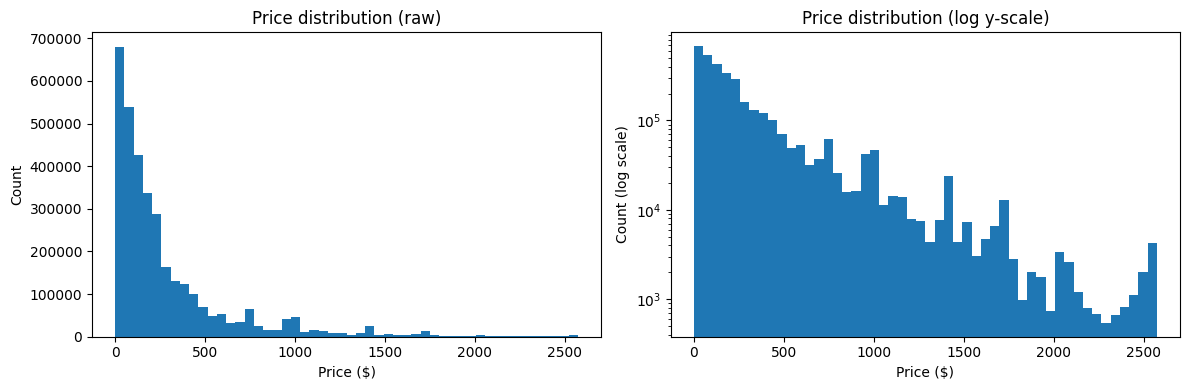

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["price"], bins=50)
axes[0].set_title("Price distribution (raw)")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Count")

axes[1].hist(df.loc[df["price"] > 0, "price"].apply(lambda x: x), bins=50, log=True)
axes[1].set_title("Price distribution (log y-scale)")
axes[1].set_xlabel("Price ($)")
axes[1].set_ylabel("Count (log scale)")

plt.tight_layout()
plt.savefig("../figures/price_distribution.png", dpi=150)
plt.show()

Most of the data is cheaper (right-skewed), so graphing on log-y scale makes it so higher priced items are more visible. Log y-scale shows not smooth decay, meaning not as simple as cheaper items are more common. Price is clustering around specific popular products or common price points.

In [20]:
session_events = df.groupby("user_session")["event_type"].apply(set)

pct_view = session_events.apply(lambda s: "view" in s).mean() * 100
pct_cart = session_events.apply(lambda s: "cart" in s).mean() * 100
pct_purchase = session_events.apply(lambda s: "purchase" in s).mean() * 100

print(f"Sessions with a view: {pct_view:.2f}%")
print(f"Sessions with a cart-add: {pct_cart:.2f}%")
print(f"Sessions with a purchase: {pct_purchase:.2f}%")

Sessions with a view: 99.98%
Sessions with a cart-add: 6.23%
Sessions with a purchase: 6.85%


purchase (6.85%) is higher than cart-add (6.23%). In a strict funnel, that shouldn't be possible. a meaningful number of sessions purchase without an observed cart-add event at all

In [21]:
sessions_with_cart = set(session_events[session_events.apply(lambda s: "cart" in s)].index)
sessions_with_purchase = set(session_events[session_events.apply(lambda s: "purchase" in s)].index)

purchase_without_cart = sessions_with_purchase - sessions_with_cart
print(f"{len(purchase_without_cart):,} sessions purchased without any observed cart-add "
      f"({len(purchase_without_cart) / len(sessions_with_purchase) * 100:.1f}% of all purchasing sessions)")

27,067 sessions purchased without any observed cart-add (53.4% of all purchasing sessions)


In [22]:
import random

sample_session_ids = random.sample(list(purchase_without_cart), 3)

for sid in sample_session_ids:
    print(f"\n=== Session {sid} ===")
    session_rows = df[df["user_session"] == sid].sort_values("event_time")
    print(session_rows[["event_time", "event_type", "product_id", "price"]].to_string(index=False))


=== Session 35f96a9d-b5b0-4101-9544-231f7732ab85 ===
               event_time event_type  product_id  price
2019-10-20 19:07:16+00:00       view     2501143  36.01
2019-10-20 19:08:33+00:00   purchase     2501143  36.01
2019-10-20 19:08:57+00:00       view     2501143  36.01
2019-10-20 19:09:22+00:00       view    26500139 167.57
2019-10-20 19:09:57+00:00   purchase    26500139 167.57

=== Session 98127baf-b5fa-4cc3-99d0-2a71affd6dac ===
               event_time event_type  product_id  price
2019-10-06 08:33:58+00:00       view     1004575 463.31
2019-10-06 08:48:43+00:00   purchase     1004575 463.31
2019-10-06 08:49:11+00:00       view     1004575 463.31

=== Session d2fd4d5c-36eb-476d-8547-e5efa042af02 ===
               event_time event_type  product_id  price
2019-10-30 01:01:52+00:00       view     4100353 489.05
2019-10-30 01:02:07+00:00   purchase     4100353 489.05


In [24]:
# Highlights sessions with purchases and if they ever added to cart. 
sample_session_ids = random.sample(list(sessions_with_purchase), 25)

for sid in sample_session_ids:
    session_rows = df[df["user_session"] == sid]
    has_cart = "cart" in session_rows["event_type"].values
    print(f"{sid}: has_cart={has_cart}")

cbe56195-58ec-47a5-8e1a-a31dfb883692: has_cart=False
02bbd6f1-e6c2-4a92-8448-c9649628c103: has_cart=False
98b6da76-dd32-492f-8aaf-5a7b92b7ed54: has_cart=True
47b111a1-a99a-40cf-a510-a40a4294f83e: has_cart=True
3567b4c5-517e-4999-8e56-1b7f889a5ae7: has_cart=False
a6abbecd-1a1b-4a93-962b-41fc9344fcd5: has_cart=False
9fe35603-f16d-4cff-a19a-a33475abb45d: has_cart=False
f097b04f-75f0-4d37-b62b-9cc8dffc3ead: has_cart=False
65cbe6d2-61b3-4539-9301-fb4e4b9e26e3: has_cart=True
4c4514a7-62fc-4c44-a5c1-b1bcbaf08d15: has_cart=False
6975e97c-3e4f-4122-9685-b4b1d0df0a9d: has_cart=False
4fbc2526-bb19-4ed6-aec2-7b788ada809e: has_cart=True
c6ccf5ed-a55a-473a-8ae4-2a3f0431b431: has_cart=False
69cc2d85-b29c-4996-bdff-9feecc3aef4a: has_cart=False
2779e33f-a944-4b1a-b393-c8262d8c5e9e: has_cart=True
f8d10431-5c99-4d77-a93f-44d57ce9890b: has_cart=False
b554d70c-0758-4077-b424-c8403942f72d: has_cart=False
b399b322-3259-4e15-aecd-b42fb30e4b59: has_cart=False
cc845ecd-7fdd-49e2-8b4f-99bcc49dd19b: has_cart=True